# Analyze JobC — corruption robustness benchmark

Sections:

0. **Setup and Loader** — paths, imports, and helpers to read `data/outputs/jobC_corruption/`.
1. **Summary metrics per model / category / corruption / severity** — the detailed table requested in `PLAN.md`, plus category-averaged aggregates.
2. **Graphical comparison** — one robustness figure per metric, averaged over categories and split by model.
3. **JobC vs clean reference (JobA / JobB)** — compare corrupted runs against the matching clean baseline for the same dataset family.
4. **Coherence / sanity checks** — completeness, monotonicity vs severity, threshold stability, and runtime consistency.
5. **Senior engineering interpretation** — thesis-oriented reading of the results and what to validate next.
6. **References** — academic sources used for the corruption-protocol and metric-reading guidance.


## 0. Setup


In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent

OUTPUTS = REPO / "data" / "outputs"
JOBC_DIR = OUTPUTS / "jobC_corruption"
JOBA_DIR = OUTPUTS / "jobA_val_defect_V1"
JOBB_DIR = OUTPUTS / "jobB_val_defect_V1"
ANALYSIS_DIR = JOBC_DIR / "_analysis"
ANALYSIS_DIR.mkdir(exist_ok=True)

assert JOBC_DIR.is_dir(), f"missing {JOBC_DIR}"
print("REPO    :", REPO)
print("JOBC    :", JOBC_DIR)
print("JOBA    :", JOBA_DIR if JOBA_DIR.is_dir() else "(not present)")
print("JOBB    :", JOBB_DIR if JOBB_DIR.is_dir() else "(not present)")
print("ANALYSIS:", ANALYSIS_DIR)


REPO    : C:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection
JOBC    : C:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection\data\outputs\jobC_corruption
JOBA    : C:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection\data\outputs\jobA_val_defect_V1
JOBB    : C:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection\data\outputs\jobB_val_defect_V1
ANALYSIS: C:\Users\Usuario\Desktop\Thesis\Pipeline\Real-time-visual-defect-detection\data\outputs\jobC_corruption\_analysis


## 0. Loader


In [13]:
def short_model_name(model: str) -> str:
    return model.replace("anomalib_", "")


def parse_timestamp(name: str) -> str:
    m = re.search(r"(\d{8}_\d{6})$", name)
    return m.group(1) if m else ""


def normalize_dataset_family(raw_format: str | None, dataset_path: str | None, run_dir: str) -> str:
    parts = [str(raw_format or ""), str(dataset_path or ""), run_dir]
    text = " ".join(parts).lower()
    if "real_iad" in text or "realiad" in text:
        return "realiad"
    if "deceuninck" in text:
        return "deceuninck"
    if raw_format and raw_format != "auto":
        return str(raw_format).lower()
    return "unknown"


def infer_category(dataset_path: str | None, run_dir: str, dataset_family: str) -> str:
    if dataset_path:
        path = Path(dataset_path)
        if path.name:
            category = path.name
            if category.lower() not in {"jobb_val_defect_deceuninck", "jobb_deceuninck", "content", "work"}:
                return category
        if path.parent.name:
            return path.parent.name
    if dataset_family == "deceuninck":
        return "deceuninck"
    m = re.match(r"jobC_[^_]+_(.+?)_(?:anomalib_|subspacead|rd4ad)", run_dir)
    if m:
        return m.group(1)
    return "unknown"


def load_predictions(run_dir: Path, model: str, validation: bool = False) -> pd.DataFrame:
    fname = ("validation_predictions_" if validation else "predictions_") + f"{model}.json"
    path = run_dir / fname
    if not path.is_file():
        return pd.DataFrame()
    return pd.DataFrame(json.loads(path.read_text(encoding="utf-8")))


def load_live_status(run_dir: Path, model: str) -> dict:
    path = run_dir / f"live_status_{model}.json"
    if not path.is_file():
        return {}
    return json.loads(path.read_text(encoding="utf-8"))


def load_jobc_runs(directory: Path) -> pd.DataFrame:
    rows = []
    for run_dir in sorted(p for p in directory.iterdir() if p.is_dir() and not p.name.startswith("_")):
        summary_path = run_dir / "benchmark_summary.json"
        if not summary_path.is_file():
            continue
        summary = json.loads(summary_path.read_text(encoding="utf-8"))
        dataset_cfg = summary.get("dataset", {})
        dataset_path = dataset_cfg.get("path")
        dataset_family = normalize_dataset_family(dataset_cfg.get("format"), dataset_path, run_dir.name)
        category = infer_category(dataset_path, run_dir.name, dataset_family)
        corruption = summary.get("corruption", {})
        for model_row in summary.get("models", []):
            live = load_live_status(run_dir, model_row["model"])
            rows.append({
                "job": "JobC",
                "run_dir": run_dir.name,
                "run_timestamp": parse_timestamp(run_dir.name),
                "dataset_family": dataset_family,
                "category": category,
                "dataset_path": dataset_path,
                "model": model_row["model"],
                "corruption_type": corruption.get("type"),
                "severity": corruption.get("severity"),
                "corruption_enabled": corruption.get("enabled", False),
                "train_samples": model_row.get("train_samples"),
                "val_samples": model_row.get("val_samples"),
                "test_samples": model_row.get("test_samples"),
                "auroc": model_row.get("auroc"),
                "aupr": model_row.get("aupr"),
                "f1": model_row.get("f1"),
                "precision": model_row.get("precision"),
                "recall": model_row.get("recall"),
                "accuracy": model_row.get("accuracy"),
                "recall_at_fpr_1pct": model_row.get("recall_at_fpr_1pct"),
                "recall_at_fpr_5pct": model_row.get("recall_at_fpr_5pct"),
                "macro_recall": model_row.get("macro_recall"),
                "weighted_recall": model_row.get("weighted_recall"),
                "val_auroc": model_row.get("val_auroc"),
                "val_aupr": model_row.get("val_aupr"),
                "val_f1": model_row.get("val_f1"),
                "val_precision": model_row.get("val_precision"),
                "val_recall": model_row.get("val_recall"),
                "val_accuracy": model_row.get("val_accuracy"),
                "threshold_mode": model_row.get("threshold_mode"),
                "threshold_used": model_row.get("threshold_used"),
                "fit_seconds": model_row.get("fit_seconds"),
                "predict_seconds": model_row.get("predict_seconds"),
                "ms_per_image": model_row.get("ms_per_image"),
                "fps": model_row.get("fps"),
                "peak_vram_mb": model_row.get("peak_vram_mb"),
                "mean_latency_ms": live.get("mean_latency_ms"),
                "p95_latency_ms": live.get("p95_latency_ms"),
                "frames_seen": live.get("frames_seen"),
                "decisions_emitted": live.get("decisions_emitted"),
                "fail_count": live.get("fail_count"),
                "per_defect_recall": model_row.get("per_defect_recall", {}),
                "per_defect_support": model_row.get("per_defect_support", {}),
            })
    return pd.DataFrame(rows)


def load_clean_runs(directory: Path, source_job: str) -> pd.DataFrame:
    if not directory.is_dir():
        return pd.DataFrame()
    rows = []
    for run_dir in sorted(p for p in directory.iterdir() if p.is_dir() and not p.name.startswith("_")):
        summary_path = run_dir / "benchmark_summary.json"
        if not summary_path.is_file():
            continue
        summary = json.loads(summary_path.read_text(encoding="utf-8"))
        dataset_cfg = summary.get("dataset", {})
        dataset_path = dataset_cfg.get("path")
        dataset_family = normalize_dataset_family(dataset_cfg.get("format"), dataset_path, run_dir.name)
        category = infer_category(dataset_path, run_dir.name, dataset_family)
        for model_row in summary.get("models", []):
            rows.append({
                "source_job": source_job,
                "run_dir": run_dir.name,
                "run_timestamp": parse_timestamp(run_dir.name),
                "dataset_family": dataset_family,
                "category": category,
                "dataset_path": dataset_path,
                "model": model_row["model"],
                "auroc": model_row.get("auroc"),
                "aupr": model_row.get("aupr"),
                "f1": model_row.get("f1"),
                "precision": model_row.get("precision"),
                "recall": model_row.get("recall"),
                "accuracy": model_row.get("accuracy"),
                "recall_at_fpr_1pct": model_row.get("recall_at_fpr_1pct"),
                "recall_at_fpr_5pct": model_row.get("recall_at_fpr_5pct"),
                "macro_recall": model_row.get("macro_recall"),
                "weighted_recall": model_row.get("weighted_recall"),
                "val_auroc": model_row.get("val_auroc"),
                "val_aupr": model_row.get("val_aupr"),
                "val_f1": model_row.get("val_f1"),
                "val_precision": model_row.get("val_precision"),
                "val_recall": model_row.get("val_recall"),
                "val_accuracy": model_row.get("val_accuracy"),
                "threshold_mode": model_row.get("threshold_mode"),
                "threshold_used": model_row.get("threshold_used"),
                "fit_seconds": model_row.get("fit_seconds"),
                "predict_seconds": model_row.get("predict_seconds"),
                "ms_per_image": model_row.get("ms_per_image"),
                "fps": model_row.get("fps"),
                "peak_vram_mb": model_row.get("peak_vram_mb"),
            })
    return pd.DataFrame(rows)


def latest_clean_baseline(clean_df: pd.DataFrame) -> pd.DataFrame:
    if clean_df.empty:
        return clean_df.copy()
    ordered = clean_df.sort_values(
        ["source_job", "dataset_family", "category", "model", "run_timestamp", "run_dir"]
    )
    return ordered.drop_duplicates(
        ["source_job", "dataset_family", "category", "model"],
        keep="last",
    )


def baseline_source_for_family(dataset_family: str) -> str | None:
    mapping = {"realiad": "JobA", "deceuninck": "JobB"}
    return mapping.get(dataset_family)


METRICS = [
    "auroc",
    "aupr",
    "f1",
    "precision",
    "recall",
    "accuracy",
    "recall_at_fpr_1pct",
    "recall_at_fpr_5pct",
]
QUALITY_METRICS = ["auroc", "aupr", "f1", "precision", "recall", "recall_at_fpr_1pct"]

jobc_df = load_jobc_runs(JOBC_DIR)
clean_df = pd.concat(
    [load_clean_runs(JOBA_DIR, "JobA"), load_clean_runs(JOBB_DIR, "JobB")],
    ignore_index=True,
)
clean_latest = latest_clean_baseline(clean_df)

assert not jobc_df.empty, f"no JobC runs found under {JOBC_DIR}"

print(f"Loaded {len(jobc_df)} JobC rows")
print("Dataset families:", sorted(jobc_df["dataset_family"].dropna().unique()))
print("Categories      :", sorted(jobc_df["category"].dropna().unique()))
print("Models          :", sorted(jobc_df["model"].dropna().unique()))
print("Corruptions     :", sorted(jobc_df["corruption_type"].dropna().unique()))
print("Severities      :", sorted(jobc_df["severity"].dropna().unique()))

inventory = (
    jobc_df.groupby(["dataset_family", "category", "model", "corruption_type", "severity"])
    .size()
    .rename("runs")
    .reset_index()
)
display(inventory.head(12))


Loaded 115 JobC rows
Dataset families: ['realiad']
Categories      : ['audiojack', 'button_battery', 'plastic_plug', 'regulator', 'woodstick']
Models          : ['anomalib_csflow', 'anomalib_padim', 'anomalib_stfpm']
Corruptions     : ['gaussian_blur', 'jpeg_compression', 'motion_blur']
Severities      : [np.int64(1), np.int64(3), np.int64(5)]


,dataset_family,category,model,corruption_type,severity,runs
0,realiad,audiojack,anomalib_csflow,gaussian_blur,1,1
1,realiad,audiojack,anomalib_csflow,gaussian_blur,3,1
2,realiad,audiojack,anomalib_csflow,gaussian_blur,5,1
3,realiad,audiojack,anomalib_csflow,jpeg_compression,1,1
4,realiad,audiojack,anomalib_csflow,jpeg_compression,3,1
5,realiad,audiojack,anomalib_csflow,jpeg_compression,5,1
6,realiad,audiojack,anomalib_csflow,motion_blur,1,1
7,realiad,audiojack,anomalib_csflow,motion_blur,3,1
8,realiad,audiojack,anomalib_csflow,motion_blur,5,1
9,realiad,audiojack,anomalib_padim,gaussian_blur,1,1


## 1. Summary metrics per model / category / corruption / severity


In [3]:
detail_cols = [
    "dataset_family", "category", "model", "corruption_type", "severity",
    "train_samples", "val_samples", "test_samples",
    "auroc", "aupr", "f1", "precision", "recall", "accuracy",
    "recall_at_fpr_1pct", "recall_at_fpr_5pct",
    "threshold_mode", "threshold_used",
    "fit_seconds", "predict_seconds", "ms_per_image", "p95_latency_ms", "fps", "peak_vram_mb",
]
detail_table = (
    jobc_df[detail_cols]
    .sort_values(["dataset_family", "category", "model", "corruption_type", "severity"])
    .reset_index(drop=True)
)
detail_table.to_csv(ANALYSIS_DIR / "table_jobc_detailed.tsv", sep="\t", index=False)
display(detail_table.round(4))


,dataset_family,category,model,corruption_type,severity,train_samples,val_samples,test_samples,auroc,aupr,...,recall_at_fpr_1pct,recall_at_fpr_5pct,threshold_mode,threshold_used,fit_seconds,predict_seconds,ms_per_image,p95_latency_ms,fps,peak_vram_mb
0,realiad,audiojack,anomalib_csflow,gaussian_blur,1,354,92,564,0.9284,0.9806,...,0.1871,0.6602,val_f1,2.8971,59.6600,53.2334,94.3854,98.1895,10.5949,6491.519
1,realiad,audiojack,anomalib_csflow,gaussian_blur,3,354,92,564,0.9074,0.9748,...,0.1226,0.5140,val_f1,2.8909,58.2414,53.3987,94.6785,99.7450,10.5621,6491.519
2,realiad,audiojack,anomalib_csflow,gaussian_blur,5,354,92,564,0.8127,0.9432,...,0.0839,0.2172,val_f1,2.9304,58.3327,52.5623,93.1955,96.0459,10.7301,6491.519
3,realiad,audiojack,anomalib_csflow,jpeg_compression,1,354,92,564,0.8991,0.9734,...,0.1828,0.5570,val_f1,2.8872,58.1634,53.5391,94.9275,99.2051,10.5344,6491.519
4,realiad,audiojack,anomalib_csflow,jpeg_compression,3,354,92,564,0.9073,0.9752,...,0.1570,0.6237,val_f1,2.8893,58.0882,52.6417,93.3364,95.8363,10.7139,6491.519
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,realiad,woodstick,anomalib_stfpm,jpeg_compression,3,360,90,551,0.6828,0.9012,...,0.0511,0.1089,val_f1,0.0126,16.6783,7.3733,13.3817,14.4870,74.7288,3111.561
111,realiad,woodstick,anomalib_stfpm,jpeg_compression,5,360,90,551,0.6066,0.8751,...,0.1111,0.1556,val_f1,0.0155,16.8027,7.5091,13.6281,14.4778,73.3776,3111.561
112,realiad,woodstick,anomalib_stfpm,motion_blur,1,360,90,551,0.7203,0.9051,...,0.0156,0.1889,val_f1,0.0109,16.5948,7.2037,13.0738,13.8526,76.4888,3111.561
113,realiad,woodstick,anomalib_stfpm,motion_blur,3,360,90,551,0.6298,0.8749,...,0.0222,0.1489,val_f1,0.0125,16.5931,7.6064,13.8048,14.4500,72.4388,3111.561


In [4]:
category_mean = (
    jobc_df.groupby(["dataset_family", "model", "corruption_type", "severity"], as_index=False)[
        METRICS + ["ms_per_image", "p95_latency_ms", "fps"]
    ]
    .mean(numeric_only=True)
    .sort_values(["dataset_family", "model", "corruption_type", "severity"])
)
category_mean.to_csv(ANALYSIS_DIR / "table_jobc_category_mean.tsv", sep="\t", index=False)
display(category_mean.round(4))


,dataset_family,model,corruption_type,severity,auroc,aupr,f1,precision,recall,accuracy,recall_at_fpr_1pct,recall_at_fpr_5pct,ms_per_image,p95_latency_ms,fps
0,realiad,anomalib_csflow,gaussian_blur,1,0.7000,0.9069,0.9065,0.8325,0.9951,0.8310,0.1267,0.2890,93.7873,97.6783,10.6626
1,realiad,anomalib_csflow,gaussian_blur,3,0.6804,0.8972,0.9029,0.8230,1.0000,0.8230,0.0784,0.2429,93.5887,97.5423,10.6860
2,realiad,anomalib_csflow,gaussian_blur,5,0.6687,0.8875,0.9014,0.8206,1.0000,0.8206,0.0619,0.1519,93.0474,95.8960,10.7472
3,realiad,anomalib_csflow,jpeg_compression,1,0.7009,0.9071,0.9111,0.8455,0.9887,0.8407,0.1308,0.2710,94.1466,97.8827,10.6225
4,realiad,anomalib_csflow,jpeg_compression,3,0.6965,0.9043,0.9079,0.8389,0.9897,0.8345,0.1260,0.2871,94.1302,97.4888,10.6244
5,realiad,anomalib_csflow,jpeg_compression,5,0.6553,0.8893,0.9027,0.8242,0.9978,0.8230,0.1181,0.2067,94.2211,97.1927,10.6137
6,realiad,anomalib_csflow,motion_blur,1,0.6899,0.9042,0.9056,0.8363,0.9881,0.8305,0.1106,0.2652,94.0776,97.5855,10.6302
7,realiad,anomalib_csflow,motion_blur,3,0.6374,0.8870,0.9013,0.8225,0.9968,0.8203,0.1055,0.1859,94.3512,97.7581,10.5988
8,realiad,anomalib_csflow,motion_blur,5,0.6108,0.8735,0.9029,0.8230,1.0000,0.8230,0.0508,0.1439,94.4284,97.6471,10.5904
9,realiad,anomalib_padim,gaussian_blur,1,0.8524,0.9553,0.8205,0.9553,0.7259,0.7441,0.1766,0.4154,4.6321,4.8879,215.9147


## §2 Graphical comparison

One figure per metric. Within each figure, each subplot corresponds to one model and each line corresponds
to one corruption type. Values are averaged over categories, exactly as requested for the robustness view.

When a clean reference exists, the dashed horizontal line is the mean clean baseline from `JobA` (for
`realiad`) or `JobB` (for `deceuninck`) over the same set of categories present in `JobC`.


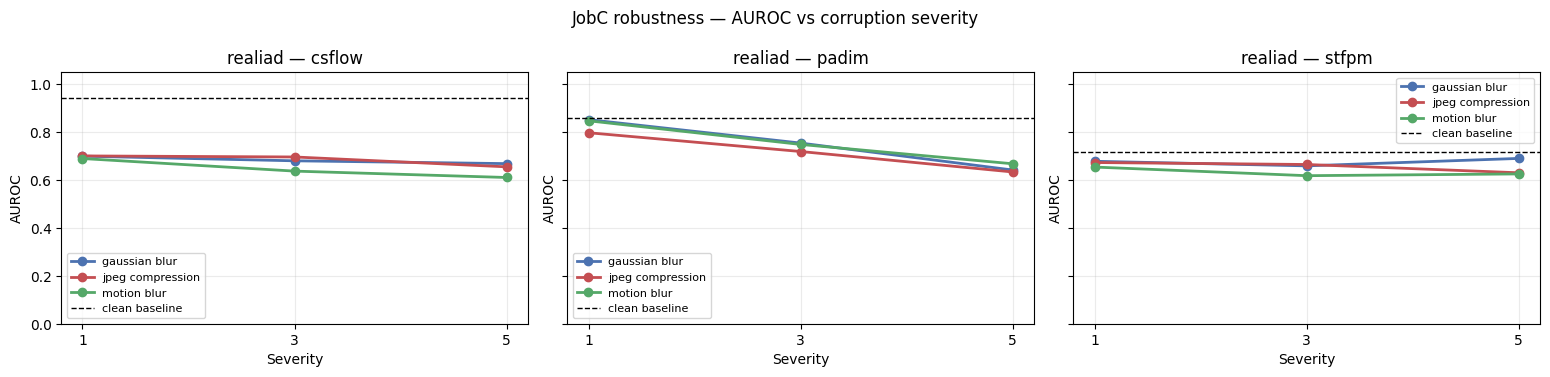

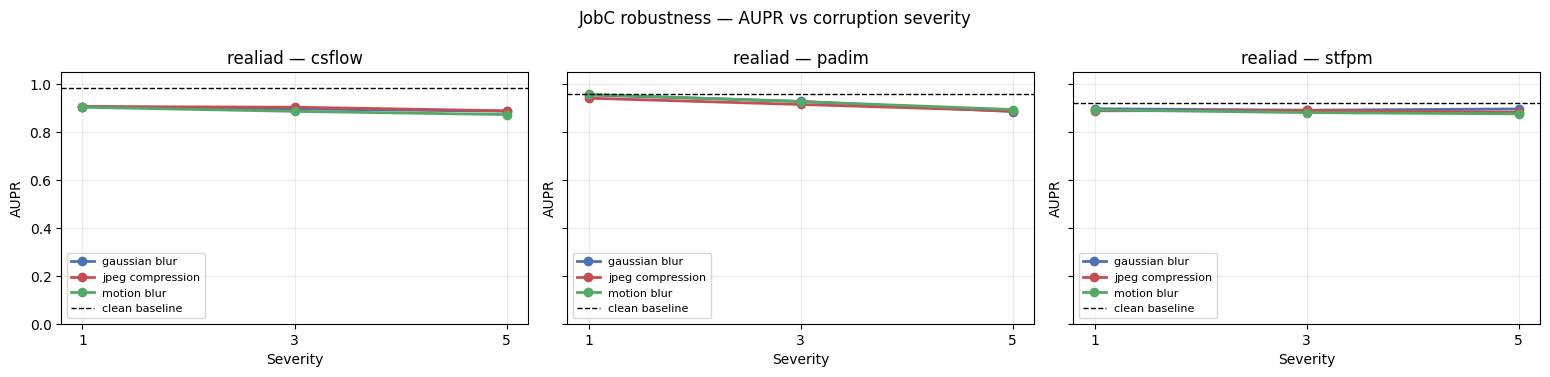

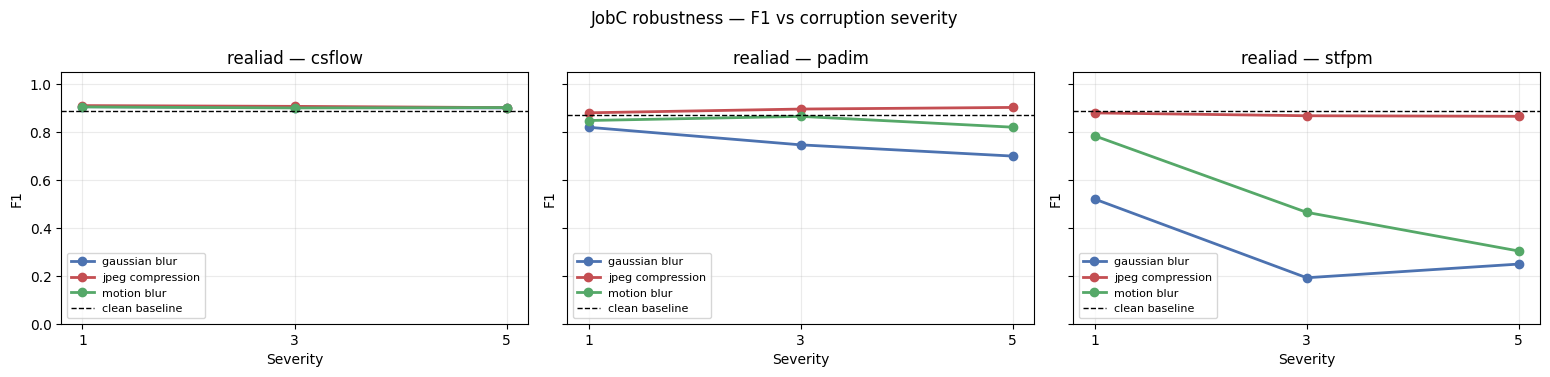

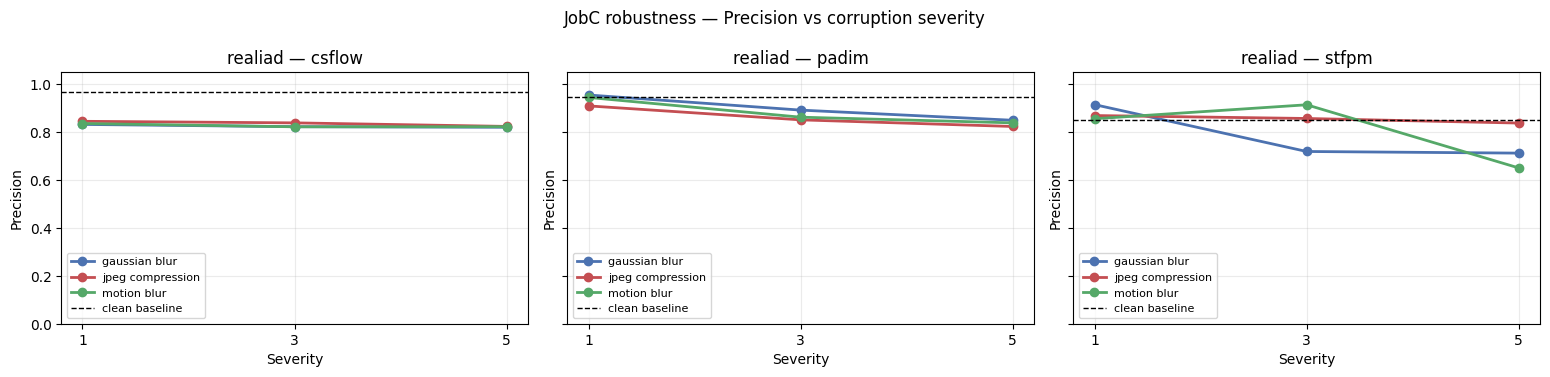

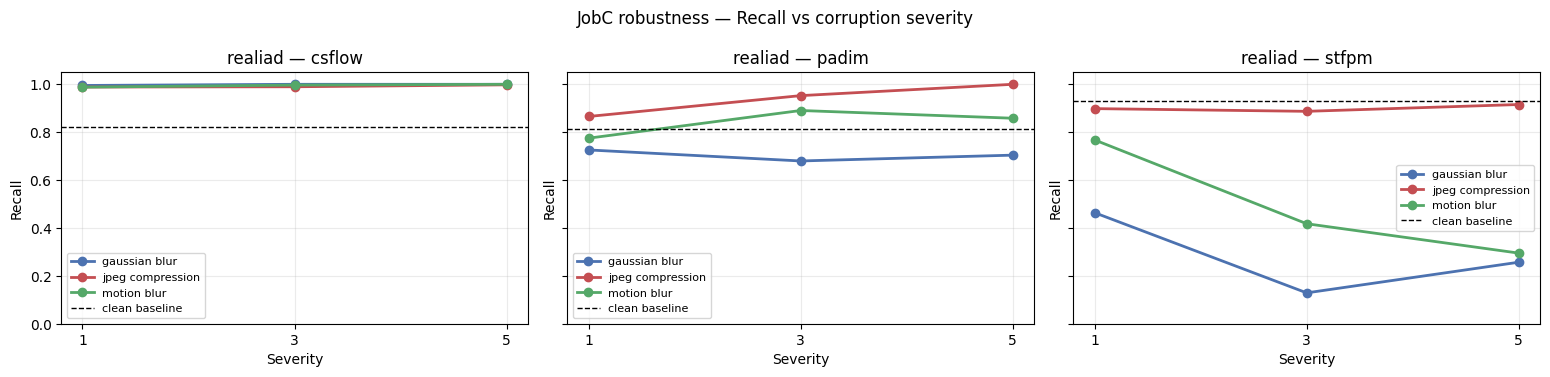

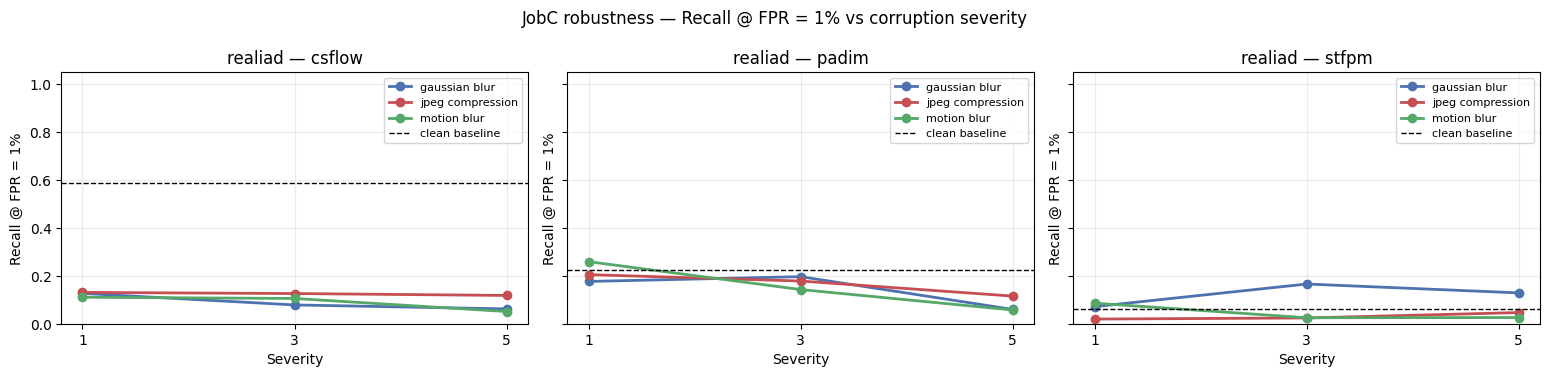

In [5]:
clean_candidates = clean_latest.copy()
jobc_for_merge = jobc_df.copy()
jobc_for_merge["baseline_job"] = jobc_for_merge["dataset_family"].map(baseline_source_for_family)

comparison = jobc_for_merge.merge(
    clean_candidates,
    left_on=["baseline_job", "dataset_family", "category", "model"],
    right_on=["source_job", "dataset_family", "category", "model"],
    how="left",
    suffixes=("_jobc", "_clean"),
)

clean_reference_mean = (
    comparison.dropna(subset=["source_job"])
    .groupby(["dataset_family", "model"], as_index=False)[[f"{m}_clean" for m in QUALITY_METRICS]]
    .mean(numeric_only=True)
)

model_order = sorted(jobc_df["model"].unique())
corruption_order = sorted(jobc_df["corruption_type"].unique())
severity_order = sorted(jobc_df["severity"].unique())
family_order = sorted(jobc_df["dataset_family"].unique())

metric_labels = {
    "auroc": "AUROC",
    "aupr": "AUPR",
    "f1": "F1",
    "precision": "Precision",
    "recall": "Recall",
    "recall_at_fpr_1pct": "Recall @ FPR = 1%",
}

colors = {
    "gaussian_blur": "#4C72B0",
    "motion_blur": "#55A868",
    "jpeg_compression": "#C44E52",
}

for metric in QUALITY_METRICS:
    fig, axes = plt.subplots(
        len(family_order),
        len(model_order),
        figsize=(5.2 * len(model_order), 3.8 * len(family_order)),
        sharex=True,
        sharey=True,
        squeeze=False,
    )
    for i, family in enumerate(family_order):
        for j, model in enumerate(model_order):
            ax = axes[i, j]
            sub = category_mean[
                (category_mean["dataset_family"] == family) & (category_mean["model"] == model)
            ]
            if sub.empty:
                ax.set_visible(False)
                continue
            for corruption in corruption_order:
                line = sub[sub["corruption_type"] == corruption].sort_values("severity")
                if line.empty:
                    continue
                ax.plot(
                    line["severity"],
                    line[metric],
                    marker="o",
                    lw=2,
                    color=colors.get(corruption, None),
                    label=corruption.replace("_", " "),
                )
            ref = clean_reference_mean[
                (clean_reference_mean["dataset_family"] == family) & (clean_reference_mean["model"] == model)
            ]
            if not ref.empty:
                ax.axhline(
                    ref.iloc[0][f"{metric}_clean"],
                    color="black",
                    lw=1,
                    ls="--",
                    label="clean baseline",
                )
            ax.set_title(f"{family} — {short_model_name(model)}")
            ax.set_xlabel("Severity")
            ax.set_ylabel(metric_labels[metric])
            ax.set_xticks(severity_order)
            ax.set_ylim(0, 1.05)
            ax.grid(alpha=0.25)
            ax.legend(fontsize=8, loc="best")
    fig.suptitle(f"JobC robustness — {metric_labels[metric]} vs corruption severity", fontsize=12)
    fig.tight_layout()
    plt.show()


## §3 JobC vs clean reference (JobA / JobB)

`JobC` is only interpretable when compared to the clean baseline that used the same dataset family:

- `realiad` runs should be compared against `JobA` clean / `val_f1` baselines.
- `deceuninck` runs should be compared against `JobB`.

The tables below compute both the raw clean numbers and the `JobC - clean` delta for the same
`(dataset_family, category, model)` cell whenever a matching clean baseline exists.


In [6]:
compare_cols = [
    "dataset_family", "baseline_job", "category", "model", "corruption_type", "severity",
    "auroc_jobc", "auroc_clean",
    "aupr_jobc", "aupr_clean",
    "f1_jobc", "f1_clean",
    "precision_jobc", "precision_clean",
    "recall_jobc", "recall_clean",
    "ms_per_image_jobc", "ms_per_image_clean",
    "threshold_used_jobc", "threshold_used_clean",
]

for metric in ["auroc", "aupr", "f1", "precision", "recall", "ms_per_image"]:
    comparison[f"{metric}_delta"] = comparison[f"{metric}_jobc"] - comparison[f"{metric}_clean"]

matched = comparison.dropna(subset=["source_job"]).copy()
matched_detail = (
    matched[compare_cols + [f"{m}_delta" for m in ["auroc", "aupr", "f1", "precision", "recall", "ms_per_image"]]]
    .sort_values(["dataset_family", "category", "model", "corruption_type", "severity"])
    .reset_index(drop=True)
)
matched_detail.to_csv(ANALYSIS_DIR / "compare_jobc_vs_clean_detailed.tsv", sep="\t", index=False)
display(matched_detail.round(4))


,dataset_family,baseline_job,category,model,corruption_type,severity,auroc_jobc,auroc_clean,aupr_jobc,aupr_clean,...,ms_per_image_jobc,ms_per_image_clean,threshold_used_jobc,threshold_used_clean,auroc_delta,aupr_delta,f1_delta,precision_delta,recall_delta,ms_per_image_delta
0,realiad,JobA,audiojack,anomalib_csflow,gaussian_blur,1,0.9284,0.9411,0.9806,0.9866,...,94.3854,77.1128,2.8971,534.8540,-0.0127,-0.0059,0.0293,-0.1171,0.1763,17.2727
1,realiad,JobA,audiojack,anomalib_csflow,gaussian_blur,3,0.9074,0.9411,0.9748,0.9866,...,94.6785,77.1128,2.8909,534.8540,-0.0338,-0.0117,0.0141,-0.1427,0.1763,17.5658
2,realiad,JobA,audiojack,anomalib_csflow,gaussian_blur,5,0.8127,0.9411,0.9432,0.9866,...,93.1955,77.1128,2.9304,534.8540,-0.1284,-0.0434,0.0141,-0.1427,0.1763,16.0827
3,realiad,JobA,audiojack,anomalib_csflow,jpeg_compression,1,0.8991,0.9411,0.9734,0.9866,...,94.9275,77.1128,2.8872,534.8540,-0.0420,-0.0131,0.0450,-0.0779,0.1613,17.8147
4,realiad,JobA,audiojack,anomalib_csflow,jpeg_compression,3,0.9073,0.9411,0.9752,0.9866,...,93.3364,77.1128,2.8893,534.8540,-0.0338,-0.0114,0.0331,-0.1025,0.1656,16.2236
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,realiad,JobA,woodstick,anomalib_padim,jpeg_compression,3,0.7422,0.8757,0.9250,0.9643,...,4.6888,10.9029,28.5973,28.9157,-0.1335,-0.0393,-0.0211,-0.1014,0.0778,-6.2141
68,realiad,JobA,woodstick,anomalib_padim,jpeg_compression,5,0.5076,0.8757,0.8522,0.9643,...,4.7041,10.9029,33.7072,28.9157,-0.3681,-0.1121,-0.0211,-0.1014,0.0778,-6.1988
69,realiad,JobA,woodstick,anomalib_padim,motion_blur,1,0.8042,0.8757,0.9443,0.9643,...,4.7712,10.9029,26.9078,28.9157,-0.0716,-0.0201,-0.0418,-0.0277,-0.0556,-6.1317
70,realiad,JobA,woodstick,anomalib_padim,motion_blur,3,0.6615,0.8757,0.8996,0.9643,...,4.7640,10.9029,28.7833,28.9157,-0.2143,-0.0647,-0.0213,-0.1003,0.0756,-6.1389


In [7]:
compare_summary = (
    matched.groupby(["dataset_family", "baseline_job", "model", "corruption_type", "severity"], as_index=False)[
        [
            "auroc_jobc", "auroc_clean", "auroc_delta",
            "aupr_jobc", "aupr_clean", "aupr_delta",
            "f1_jobc", "f1_clean", "f1_delta",
            "precision_jobc", "precision_clean", "precision_delta",
            "recall_jobc", "recall_clean", "recall_delta",
            "ms_per_image_jobc", "ms_per_image_clean", "ms_per_image_delta",
        ]
    ]
    .mean(numeric_only=True)
    .sort_values(["dataset_family", "model", "corruption_type", "severity"])
)
compare_summary.to_csv(ANALYSIS_DIR / "compare_jobc_vs_clean_summary.tsv", sep="\t", index=False)
display(compare_summary.round(4))

missing_baseline = comparison[comparison["source_job"].isna()][
    ["dataset_family", "category", "model"]
].drop_duplicates()
if missing_baseline.empty:
    print("All JobC rows found a matching clean reference.")
else:
    print("Missing clean reference for these cells:")
    display(missing_baseline.sort_values(["dataset_family", "category", "model"]).reset_index(drop=True))


,dataset_family,baseline_job,model,corruption_type,severity,auroc_jobc,auroc_clean,auroc_delta,aupr_jobc,aupr_clean,...,f1_delta,precision_jobc,precision_clean,precision_delta,recall_jobc,recall_clean,recall_delta,ms_per_image_jobc,ms_per_image_clean,ms_per_image_delta
0,realiad,JobA,anomalib_csflow,gaussian_blur,1,0.9284,0.9411,-0.0127,0.9806,0.9866,...,0.0293,0.8501,0.9672,-0.1171,1.0000,0.8237,0.1763,94.3854,77.1128,17.2727
1,realiad,JobA,anomalib_csflow,gaussian_blur,3,0.9074,0.9411,-0.0338,0.9748,0.9866,...,0.0141,0.8245,0.9672,-0.1427,1.0000,0.8237,0.1763,94.6785,77.1128,17.5658
2,realiad,JobA,anomalib_csflow,gaussian_blur,5,0.8127,0.9411,-0.1284,0.9432,0.9866,...,0.0141,0.8245,0.9672,-0.1427,1.0000,0.8237,0.1763,93.1955,77.1128,16.0827
3,realiad,JobA,anomalib_csflow,jpeg_compression,1,0.8991,0.9411,-0.0420,0.9734,0.9866,...,0.0450,0.8893,0.9672,-0.0779,0.9849,0.8237,0.1613,94.9275,77.1128,17.8147
4,realiad,JobA,anomalib_csflow,jpeg_compression,3,0.9073,0.9411,-0.0338,0.9752,0.9866,...,0.0331,0.8647,0.9672,-0.1025,0.9892,0.8237,0.1656,93.3364,77.1128,16.2236
5,realiad,JobA,anomalib_csflow,jpeg_compression,5,0.8121,0.9411,-0.1290,0.9490,0.9866,...,0.0141,0.8245,0.9672,-0.1427,1.0000,0.8237,0.1763,93.3104,77.1128,16.1977
6,realiad,JobA,anomalib_csflow,motion_blur,1,0.9140,0.9411,-0.0271,0.9770,0.9866,...,0.0365,0.8641,0.9672,-0.1031,0.9978,0.8237,0.1742,93.7844,77.1128,16.6716
7,realiad,JobA,anomalib_csflow,motion_blur,3,0.7442,0.9411,-0.1969,0.9364,0.9866,...,0.0141,0.8245,0.9672,-0.1427,1.0000,0.8237,0.1763,94.7905,77.1128,17.6777
8,realiad,JobA,anomalib_csflow,motion_blur,5,0.7155,0.9411,-0.2256,0.9262,0.9866,...,0.0141,0.8245,0.9672,-0.1427,1.0000,0.8237,0.1763,93.5780,77.1128,16.4652
9,realiad,JobA,anomalib_padim,gaussian_blur,1,0.8524,0.8585,-0.0061,0.9553,0.9608,...,-0.0499,0.9553,0.9461,0.0092,0.7259,0.8119,-0.0861,4.6321,11.1086,-6.4766


Missing clean reference for these cells:


,dataset_family,category,model
0,realiad,plastic_plug,anomalib_csflow
1,realiad,regulator,anomalib_csflow
2,realiad,regulator,anomalib_stfpm
3,realiad,woodstick,anomalib_csflow
4,realiad,woodstick,anomalib_stfpm


## §4 Coherence / sanity checks

Robustness runs are easy to misread. These checks focus on four failure modes:

1. **Incomplete grid** — missing `(category × model × corruption × severity)` cells.
2. **Non-monotonic severity response** — for threshold-independent metrics, higher severity should usually not improve the ranking quality.
3. **Threshold drift** — `threshold_used` comes from clean validation; if it changes a lot across corruption-only reruns, re-check training randomness and config parity.
4. **Runtime consistency** — `frames_seen`, `decisions_emitted`, `test_samples`, and `mean_latency_ms` should agree across the JSON artifacts.


In [ ]:
JOBC_ACTIVE_DATASET_FAMILIES = ["realiad"]
JOBC_DESIGN = {
    "realiad": {
        "categories": ["audiojack", "button_battery", "plastic_plug", "regulator", "woodstick"],
        "models": ["anomalib_csflow", "anomalib_padim", "anomalib_stfpm"],
        "corruptions": ["gaussian_blur", "jpeg_compression", "motion_blur"],
        "severities": [1, 3, 5],
    },
    "deceuninck": {
        "categories": ["deceuninck"],
        "models": ["anomalib_csflow", "anomalib_padim", "anomalib_stfpm"],
        "corruptions": ["gaussian_blur", "jpeg_compression", "motion_blur"],
        "severities": [1, 3, 5],
    },
}

design_rows = []
for family in JOBC_ACTIVE_DATASET_FAMILIES:
    spec = JOBC_DESIGN[family]
    for category in spec["categories"]:
        for model in spec["models"]:
            for corruption in spec["corruptions"]:
                for severity in spec["severities"]:
                    design_rows.append({
                        "dataset_family": family,
                        "category": category,
                        "model": model,
                        "corruption_type": corruption,
                        "severity": severity,
                    })

design_df = pd.DataFrame(design_rows)
expected_rows = len(design_df)
observed_rows = len(jobc_df)
print(f"Observed JobC rows: {observed_rows}")
print(f"Experimental-design expectation: {expected_rows}")
print(f"Active dataset families in design: {JOBC_ACTIVE_DATASET_FAMILIES}")

complete_grid = pd.MultiIndex.from_frame(
    design_df.sort_values(["dataset_family", "category", "model", "corruption_type", "severity"]),
    names=["dataset_family", "category", "model", "corruption_type", "severity"],
)
observed_grid = pd.MultiIndex.from_frame(
    jobc_df[["dataset_family", "category", "model", "corruption_type", "severity"]].drop_duplicates()
)
missing_grid = complete_grid.difference(observed_grid)
unexpected_grid = observed_grid.difference(complete_grid)
if len(missing_grid) == 0:
    print("No missing cells in the current JobC grid.")
else:
    print(f"Missing design cells: {len(missing_grid)}")
    display(pd.DataFrame(index=missing_grid).reset_index())

if len(unexpected_grid) == 0:
    print("Observed cells all belong to the declared JobC design.")
else:
    print("Observed cells outside the declared JobC design; update JOBC_DESIGN / JOBC_ACTIVE_DATASET_FAMILIES.")
    display(pd.DataFrame(index=unexpected_grid).reset_index())


In [9]:
monotonic_rows = []
for (family, category, model, corruption), sub in jobc_df.groupby(
    ["dataset_family", "category", "model", "corruption_type"]
):
    sub = sub.sort_values("severity")
    row = {
        "dataset_family": family,
        "category": category,
        "model": model,
        "corruption_type": corruption,
    }
    for metric in ["auroc", "aupr", "f1", "recall"]:
        vals = sub[["severity", metric]].dropna()
        if len(vals) >= 3:
            seq = vals[metric].tolist()
            row[f"{metric}_s1"] = seq[0]
            row[f"{metric}_s3"] = seq[1]
            row[f"{metric}_s5"] = seq[2]
            row[f"{metric}_monotonic_nonincreasing"] = seq[0] >= seq[1] >= seq[2]
    monotonic_rows.append(row)

monotonic_df = pd.DataFrame(monotonic_rows)
display(monotonic_df.round(4))

print("Monotonicity summary:")
for metric in ["auroc", "aupr", "f1", "recall"]:
    flag = f"{metric}_monotonic_nonincreasing"
    if flag in monotonic_df:
        rate = monotonic_df[flag].dropna().mean()
        print(f"  {metric}: {rate:.1%} of category-level curves are non-increasing")


,dataset_family,category,model,corruption_type,auroc_s1,auroc_s3,auroc_s5,auroc_monotonic_nonincreasing,aupr_s1,aupr_s3,aupr_s5,aupr_monotonic_nonincreasing,f1_s1,f1_s3,f1_s5,f1_monotonic_nonincreasing,recall_s1,recall_s3,recall_s5,recall_monotonic_nonincreasing
0,realiad,audiojack,anomalib_csflow,gaussian_blur,0.9284,0.9074,0.8127,True,0.9806,0.9748,0.9432,True,0.9190,0.9038,0.9038,True,1.0000,1.0000,1.0000,True
1,realiad,audiojack,anomalib_csflow,jpeg_compression,0.8991,0.9073,0.8121,False,0.9734,0.9752,0.9490,False,0.9347,0.9228,0.9038,True,0.9849,0.9892,1.0000,False
2,realiad,audiojack,anomalib_csflow,motion_blur,0.9140,0.7442,0.7155,True,0.9770,0.9364,0.9262,True,0.9261,0.9038,0.9038,True,0.9978,1.0000,1.0000,False
3,realiad,audiojack,anomalib_padim,gaussian_blur,0.8931,0.8524,0.7751,True,0.9712,0.9644,0.9414,True,0.8561,0.8757,0.9038,False,0.7677,0.8409,1.0000,False
4,realiad,audiojack,anomalib_padim,jpeg_compression,0.8824,0.8214,0.8902,False,0.9701,0.9550,0.9707,False,0.8931,0.8763,0.9038,False,0.8538,0.8452,1.0000,False
5,realiad,audiojack,anomalib_padim,motion_blur,0.8904,0.7907,0.8360,False,0.9731,0.9480,0.9570,False,0.8626,0.8985,0.9047,False,0.7828,0.9613,1.0000,False
6,realiad,audiojack,anomalib_stfpm,gaussian_blur,0.6553,0.7341,0.6500,False,0.8963,0.9300,0.8882,False,0.0380,0.0086,0.0213,False,0.0194,0.0043,0.0108,False
7,realiad,audiojack,anomalib_stfpm,jpeg_compression,0.7198,0.7819,0.6823,False,0.9108,0.9320,0.9003,False,0.8243,0.8843,0.7577,False,0.7720,0.8796,0.6624,False
8,realiad,audiojack,anomalib_stfpm,motion_blur,0.6363,0.5302,0.5591,False,0.8919,0.8640,0.8501,True,0.5271,0.0297,0.0419,False,0.3763,0.0151,0.0215,False
9,realiad,button_battery,anomalib_padim,gaussian_blur,0.8537,0.6694,0.5472,True,0.9351,0.8691,0.8469,True,0.7434,0.4561,0.2857,True,0.6043,0.3075,0.1720,True


Monotonicity summary:
  auroc: 48.6% of category-level curves are non-increasing
  aupr: 59.5% of category-level curves are non-increasing
  f1: 48.6% of category-level curves are non-increasing
  recall: 37.8% of category-level curves are non-increasing


In [10]:
threshold_stability = (
    jobc_df.groupby(["dataset_family", "category", "model"], as_index=False)
    .agg(
        threshold_min=("threshold_used", "min"),
        threshold_max=("threshold_used", "max"),
        threshold_std=("threshold_used", "std"),
        fit_seconds_mean=("fit_seconds", "mean"),
        fit_seconds_std=("fit_seconds", "std"),
    )
    .sort_values(["dataset_family", "category", "model"])
)
display(threshold_stability.round(4))


,dataset_family,category,model,threshold_min,threshold_max,threshold_std,fit_seconds_mean,fit_seconds_std
0,realiad,audiojack,anomalib_csflow,2.8872,2.9304,0.0130,58.3239,0.5190
1,realiad,audiojack,anomalib_padim,28.9560,46.3720,5.7956,7.3171,1.5236
2,realiad,audiojack,anomalib_stfpm,0.0418,0.0963,0.0171,15.3902,2.2161
3,realiad,button_battery,anomalib_padim,40.0115,60.7295,6.0137,7.0219,0.0439
4,realiad,plastic_plug,anomalib_csflow,3.3011,3.3113,0.0034,58.9819,0.1715
5,realiad,plastic_plug,anomalib_padim,32.7919,43.0057,3.8543,7.4092,0.0427
6,realiad,plastic_plug,anomalib_stfpm,0.0137,0.0226,0.0028,15.6683,0.1125
7,realiad,regulator,anomalib_csflow,3.2166,3.2259,0.0031,58.6525,0.1573
8,realiad,regulator,anomalib_padim,29.9856,43.3735,4.5473,7.0493,0.0452
9,realiad,regulator,anomalib_stfpm,0.0479,0.0727,0.0087,15.0849,0.1087


In [11]:
runtime_check = jobc_df[
    [
        "dataset_family", "category", "model", "corruption_type", "severity",
        "test_samples", "frames_seen", "decisions_emitted",
        "ms_per_image", "mean_latency_ms", "p95_latency_ms",
    ]
].copy()
runtime_check["frames_match_test"] = runtime_check["frames_seen"] == runtime_check["test_samples"]
runtime_check["decisions_match_test"] = runtime_check["decisions_emitted"] == runtime_check["test_samples"]
runtime_check["latency_delta_ms"] = runtime_check["mean_latency_ms"] - runtime_check["ms_per_image"]
display(runtime_check.round(4))


,dataset_family,category,model,corruption_type,severity,test_samples,frames_seen,decisions_emitted,ms_per_image,mean_latency_ms,p95_latency_ms,frames_match_test,decisions_match_test,latency_delta_ms
0,realiad,audiojack,anomalib_csflow,gaussian_blur,1,564,564,564,94.3854,94.3854,98.1895,True,True,0.0
1,realiad,audiojack,anomalib_csflow,gaussian_blur,3,564,564,564,94.6785,94.6785,99.7450,True,True,0.0
2,realiad,audiojack,anomalib_csflow,gaussian_blur,5,564,564,564,93.1955,93.1955,96.0459,True,True,-0.0
3,realiad,audiojack,anomalib_csflow,jpeg_compression,1,564,564,564,94.9275,94.9275,99.2051,True,True,0.0
4,realiad,audiojack,anomalib_csflow,jpeg_compression,3,564,564,564,93.3364,93.3364,95.8363,True,True,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110,realiad,woodstick,anomalib_stfpm,jpeg_compression,3,551,551,551,13.3817,13.3817,14.4870,True,True,-0.0
111,realiad,woodstick,anomalib_stfpm,jpeg_compression,5,551,551,551,13.6281,13.6281,14.4778,True,True,-0.0
112,realiad,woodstick,anomalib_stfpm,motion_blur,1,551,551,551,13.0738,13.0738,13.8526,True,True,-0.0
113,realiad,woodstick,anomalib_stfpm,motion_blur,3,551,551,551,13.8048,13.8048,14.4500,True,True,0.0


## §5 Senior engineering interpretation


In [12]:
observations = []

if not compare_summary.empty:
    for metric in ["auroc_delta", "aupr_delta", "f1_delta", "recall_delta"]:
        worst = compare_summary.loc[compare_summary[metric].idxmin()]
        observations.append(
            f"Worst mean {metric.replace('_delta', '')} delta: "
            f"{worst['corruption_type']} severity {int(worst['severity'])} on {worst['model']} "
            f"vs {worst['baseline_job']} ({worst[metric]:+.4f})."
        )

if not compare_summary.empty:
    r = compare_summary.sort_values("auroc_delta").iloc[0]
    observations.append(
        "For robustness claims, prioritize AUROC/AUPR over F1 when corruption shifts the score scale: "
        f"here the strongest average AUROC drop is {r['auroc_delta']:+.4f} for "
        f"{r['corruption_type']} severity {int(r['severity'])}, even if thresholded metrics may stay flat or improve."
    )

for metric in ["auroc", "aupr", "f1", "recall"]:
    flag = f"{metric}_monotonic_nonincreasing"
    if flag in monotonic_df:
        rate = monotonic_df[flag].dropna().mean()
        observations.append(
            f"{metric.upper()} monotonicity rate across category-level severity curves: {rate:.1%}."
        )

observations.extend(
    [
        "Validation recommendation: keep the clean-vs-corrupted comparison paired by category; category averaging is useful for the headline plot, but it can hide brittle categories.",
        "Threshold recommendation: because `threshold_used` is calibrated on validation data, any corrupted run that improves recall while AUROC/AUPR worsens should be read as a ranking degradation plus threshold-side effect, not as a true robustness gain.",
        "Configuration recommendation: verify that `train_samples`, `val_samples`, and `test_samples` stay constant inside each category. If they drift, the corruption benchmark is no longer an apples-to-apples comparison.",
        "Reporting recommendation for the thesis: publish both absolute scores and retention ratios such as `AUROC_corrupted / AUROC_clean` and `AUPR_corrupted / AUPR_clean`; that makes severity trends easier to compare across categories with different clean baselines.",
        "For the current `JobC` inventory, only `realiad` cells are present, so `JobA` is the relevant clean comparator. `JobB` should only be used when `JobC` includes `deceuninck` corruption runs.",
    ]
)

for idx, line in enumerate(observations, start=1):
    print(f"{idx}. {line}")


1. Worst mean auroc delta: motion_blur severity 5 on anomalib_csflow vs JobA (-0.2256).
2. Worst mean aupr delta: gaussian_blur severity 5 on anomalib_padim vs JobA (-0.0748).
3. Worst mean f1 delta: gaussian_blur severity 5 on anomalib_stfpm vs JobA (-0.8482).
4. Worst mean recall delta: gaussian_blur severity 5 on anomalib_stfpm vs JobA (-0.9104).
5. For robustness claims, prioritize AUROC/AUPR over F1 when corruption shifts the score scale: here the strongest average AUROC drop is -0.2256 for motion_blur severity 5, even if thresholded metrics may stay flat or improve.
6. AUROC monotonicity rate across category-level severity curves: 48.6%.
7. AUPR monotonicity rate across category-level severity curves: 59.5%.
8. F1 monotonicity rate across category-level severity curves: 48.6%.
9. RECALL monotonicity rate across category-level severity curves: 37.8%.
10. Validation recommendation: keep the clean-vs-corrupted comparison paired by category; category averaging is useful for the headl

## §6 References

1. **Hendrycks, D., & Dietterich, T. (2019).** *Benchmarking Neural Network Robustness to Common Corruptions and Perturbations.* ICLR 2019.  
   Use in this notebook: supports the common-corruption evaluation protocol and the interpretation of severity levels as a controlled robustness stress test.  
   Link: https://arxiv.org/abs/1903.12261

2. **Davis, J., & Goadrich, M. (2006).** *The Relationship Between Precision-Recall and ROC Curves.* ICML 2006.  
   Use in this notebook: justifies reading AUPR alongside AUROC when class balance is skewed and threshold-independent ranking quality is the main question.  
   Link: https://doi.org/10.1145/1143844.1143874

3. **Wang, C. et al. (2024).** *Real-IAD: A Real-World Multi-View Dataset for Benchmarking Versatile Industrial Anomaly Detection.*  
   Use in this notebook: supports the claim that Real-IAD is intentionally harder and more diverse than older saturated industrial benchmarks, so corruption robustness should be interpreted category-by-category rather than only through a single global mean.  
   Link: https://arxiv.org/abs/2403.12580
